In [1]:
# TODO: add typing annotation
# TODO: refactor variable names in capital

# Baseline LiDAR model on nuScenes

## Goal

This notebook documents the setup of a baseline LiDAR-only 3D object detector on nuScenes using MMDetection3D.

The objective is to train a clean baseline model that can later be compared against more advanced approaches such as fusion models or imbalance-mitigation variants.

## Experimental setting

The baseline is trained on:
- the nuScenes dataset prepared in the previous notebook
- a reproducible 20% training-scene subset
- the standard validation split

## Why this baseline matters

A LiDAR-only baseline is important because:
- it provides a reference point for later comparisons
- it establishes whether the training pipeline is working correctly
- it helps separate baseline performance from improvements due to fusion or other methods

## Planned outcome

This notebook should:
1. verify the MMDetection3D environment
2. identify the baseline config to use
3. confirm the subset annotation file paths
4. create a baseline training config for the reduced dataset
5. document the training command
6. prepare the experiment for reproducible execution

# Import

In [2]:
import mmengine
import mmdet
import mmdet3d

import shutil


from pathlib import Path
from typing import List, Tuple

# Setup and environment
## Define project paths
This notebook uses the same project and dataset paths as the dataset-preparation notebook.

I define them explicitly here so that the notebook is self-contained and can be run independently.

In [3]:
# TODO: check if needed
PROJECT_ROOT = Path("/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning")
MMDET3D_ROOT = PROJECT_ROOT / "external" / "mmdetection3d"
NUSCENES_ROOT = Path("/rs_scratch/users/ae04q066/nuscenes_full") #not needed
MMDET3D_DATA_ROOT = MMDET3D_ROOT / "data" / "nuscenes" #not needed

print("PROJECT_ROOT     :", PROJECT_ROOT)
print("MMDET3D_ROOT     :", MMDET3D_ROOT)
print("NUSCENES_ROOT    :", NUSCENES_ROOT)
print("MMDET3D_DATA_ROOT:", MMDET3D_DATA_ROOT)

PROJECT_ROOT     : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
MMDET3D_ROOT     : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d
NUSCENES_ROOT    : /rs_scratch/users/ae04q066/nuscenes_full
MMDET3D_DATA_ROOT: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/data/nuscenes


## Verify software environment
Before configuring the baseline model, I verify that:
- MMDetection3D is accessible
- the correct Python environment is active
- core libraries are properly installed

This ensures that training will run without unexpected environment issues.

In [4]:
print("mmengine version:", mmengine.__version__)
print("mmdet version   :", mmdet.__version__)
print("mmdet3d version :", mmdet3d.__version__)

mmengine version: 0.10.7
mmdet version   : 3.2.0
mmdet3d version : 1.4.0


The MMDetection3D environment is correctly set up.

Library versions:
- mmengine: 0.10.7
- mmdet: 3.2.0
- mmdet3d: 1.4.0

These versions are compatible and confirm that the training pipeline can be executed.

## Define the goal of this experiment
## Select the model
For the LiDAR baseline, I use the **CenterPoint** detector, which is a standard and strong baseline for nuScenes 3D object detection.

**Why CenterPoint**
- widely used benchmark model for nuScenes
- strong performance with LiDAR-only input
- fully supported in MMDetection3D

**Configuration choice**

I use the official MMDetection3D config:

`centerpoint_voxel01_second_secfpn_nus.py`

This config defines:
- voxelization-based LiDAR processing
- SECOND backbone
- SECFPN neck
- CenterPoint detection head


# Experiment definition

The default training schedule runs for 20 epochs with periodic validation during training. In practice, this results in a runtime of up to 11 days on a single H100 GPU.

With onn H100 GPU computation time reaches 11 days.

With reduced 20% subset experiment, I adopt a lighter schedule to:
- reduce wall-clock training time
- allow multiple experiments (baseline, fusion, ablations)
- still obtain meaningful results

This configuration is suitable for:
- debugging the pipeline
- obtaining a first baseline result quickly
- scaling up later if needed


## Define the goal of this experiment

The goal of this experiment is to train a strong **LiDAR-only baseline** on nuScenes. This baseline will serve as a reference for comparison with fusion models and other improvements.

In [5]:
EXPERIMENT_NAME: str = "lidar_baseline_nuscenes_20pct"

print("EXPERIMENT_NAME:", EXPERIMENT_NAME)

EXPERIMENT_NAME: lidar_baseline_nuscenes_20pct


## Select the model

I use **CenterPoint** as the baseline detector. It is a widely used and strong LiDAR-based model for nuScenes.

**Rationale**

- standard benchmark model
- strong LiDAR-only performance
- fully supported in MMDetection3D

In [6]:
MODEL_NAME: str = "CenterPoint"
MODEL_CONFIG_NAME: str = "centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py"

print("MODEL_NAME       :", MODEL_NAME)
print("MODEL_CONFIG_NAME:", MODEL_CONFIG_NAME)

MODEL_NAME       : CenterPoint
MODEL_CONFIG_NAME: centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py


## Define the configuration path

I create a separate experiment config instead of modifying the original MMDetection3D config directly. This keeps the repository clean and makes the experiment easier to reproduce.



In [7]:
from pathlib import Path

SOURCE_CONFIG_PATH: Path = (
    MMDET3D_ROOT
    / "configs"
    / "centerpoint"
    / "centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py"
)

EXPERIMENT_CONFIG_DIR: Path = MMDET3D_ROOT / "configs" / "my_experiments"
EXPERIMENT_CONFIG_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_CONFIG_PATH: Path = EXPERIMENT_CONFIG_DIR / "lidar_baseline_nuscenes_20pct.py"

print("SOURCE_CONFIG_PATH     :", SOURCE_CONFIG_PATH)
print("SOURCE exists          :", SOURCE_CONFIG_PATH.exists())
print("EXPERIMENT_CONFIG_DIR  :", EXPERIMENT_CONFIG_DIR)
print("EXPERIMENT_CONFIG_PATH :", EXPERIMENT_CONFIG_PATH)

SOURCE_CONFIG_PATH     : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/centerpoint/centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py
SOURCE exists          : True
EXPERIMENT_CONFIG_DIR  : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments
EXPERIMENT_CONFIG_PATH : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/lidar_baseline_nuscenes_20pct.py


## Copy the baseline config into the experiment folder

I now create a project-specific copy of the baseline CenterPoint config.

This copied config will be the one modified for the reduced dataset experiment.
The original MMDetection3D config remains untouched.

In [8]:
if EXPERIMENT_CONFIG_PATH.exists():
    print(EXPERIMENT_CONFIG_PATH)
    print("\nSafety rule: existing file is not overwritten automatically.")
else:
    shutil.copy2(SOURCE_CONFIG_PATH, EXPERIMENT_CONFIG_PATH)
    print("Copied source config to:")
    print(EXPERIMENT_CONFIG_PATH)

print("\nExperiment config exists:", EXPERIMENT_CONFIG_PATH.exists())

/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/lidar_baseline_nuscenes_20pct.py

Safety rule: existing file is not overwritten automatically.

Experiment config exists: True


# Config file settings

In this section, I prepare and modify the MMDetection3D config file for the baseline experiment.  
All key settings — dataset, training schedule, and data loading — are defined through this config.

The main changes define a reduced-budget training setup: a reproducible 20% training subset, a shorter training schedule, and adjusted data-loading settings. These changes reduce compute cost while keeping the experiment suitable for analysis.

## Open the config file

In [9]:
with open(EXPERIMENT_CONFIG_PATH, "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    print(f"{i+1:03d}: {line.rstrip()}")

001: _base_ = [
002:     '../_base_/datasets/nus-3d.py',
003:     '../_base_/models/centerpoint_voxel01_second_secfpn_nus.py',
004:     '../_base_/schedules/cyclic-20e.py',
005:     '../_base_/default_runtime.py'
006: ]
007: 
008: # If point cloud range is changed, the models should also change their point
009: # cloud range accordingly
010: point_cloud_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
011: 
012: # For nuScenes we usually do 10-class detection
013: class_names = [
014:     'car', 'truck', 'construction_vehicle', 'bus', 'trailer', 'barrier',
015:     'motorcycle', 'bicycle', 'pedestrian', 'traffic_cone'
016: ]
017: 
018: data_prefix = dict(
019:     pts='samples/LIDAR_TOP',
020:     img='',
021:     sweeps='sweeps/LIDAR_TOP'
022: )
023: 
024: model = dict(
025:     data_preprocessor=dict(
026:         voxel_layer=dict(point_cloud_range=point_cloud_range)
027:     ),
028:     pts_bbox_head=dict(
029:         bbox_coder=dict(pc_range=point_cloud_range[:2])
030:     ),
031:   

## Define override values
I define the main settings that will override the source config for this experiment. These values describe the reduced-budget training setup used in this notebook.

In [10]:
TRAIN_ANN_FILE: str = "subsets/nuscenes_infos_train_20pct.pkl"

MAX_EPOCHS: int = 5
VAL_INTERVAL: int = 1
TRAIN_CFG: str = f"dict(by_epoch=True, max_epochs={MAX_EPOCHS}, val_interval={VAL_INTERVAL})"

TRAIN_BATCH_SIZE: int = 4
TRAIN_NUM_WORKERS: int = 16

print("Override values:")
print("TRAIN_ANN_FILE    :", TRAIN_ANN_FILE)
print("MAX_EPOCHS        :", MAX_EPOCHS)
print("VAL_INTERVAL      :", VAL_INTERVAL)
print("TRAIN_CFG         :", TRAIN_CFG)
print("TRAIN_BATCH_SIZE  :", TRAIN_BATCH_SIZE)
print("TRAIN_NUM_WORKERS :", TRAIN_NUM_WORKERS)

Override values:
TRAIN_ANN_FILE    : subsets/nuscenes_infos_train_20pct.pkl
MAX_EPOCHS        : 5
VAL_INTERVAL      : 1
TRAIN_CFG         : dict(by_epoch=True, max_epochs=5, val_interval=1)
TRAIN_BATCH_SIZE  : 4
TRAIN_NUM_WORKERS : 16


## Write a clear and self-contained experiment config

I define an explicit experiment config that includes all required dataset and pipeline components, while controlling the key experiment settings through a small set of variables. This includes the reduced training subset, the shorter training schedule, the data-loading parameters, and a checkpoint configuration that saves progress regularly during training.

**Rationale**

- keeps the configuration fully explicit and easy to understand  
- makes the experiment reproducible and self-contained  
- allows quick adjustments through a small set of variables  
- simplifies reuse of the same setup across different models  
- adds regular checkpoints for safer long HPC runs  

In [11]:
CONFIG_TEXT: str = f"""_base_ = [
    '../_base_/datasets/nus-3d.py',
    '../_base_/models/centerpoint_voxel01_second_secfpn_nus.py',
    '../_base_/schedules/cyclic-20e.py',
    '../_base_/default_runtime.py'
]

# If point cloud range is changed, the models should also change their point
# cloud range accordingly
point_cloud_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]

# For nuScenes we usually do 10-class detection
class_names = [
    'car', 'truck', 'construction_vehicle', 'bus', 'trailer', 'barrier',
    'motorcycle', 'bicycle', 'pedestrian', 'traffic_cone'
]

data_prefix = dict(
    pts='samples/LIDAR_TOP',
    img='',
    sweeps='sweeps/LIDAR_TOP'
)

model = dict(
    data_preprocessor=dict(
        voxel_layer=dict(point_cloud_range=point_cloud_range)
    ),
    pts_bbox_head=dict(
        bbox_coder=dict(pc_range=point_cloud_range[:2])
    ),
    train_cfg=dict(
        pts=dict(point_cloud_range=point_cloud_range)
    ),
    test_cfg=dict(
        pts=dict(pc_range=point_cloud_range[:2])
    )
)

dataset_type = 'NuScenesDataset'
data_root = 'data/nuscenes/'
backend_args = None

db_sampler = dict(
    data_root=data_root,
    info_path=data_root + 'nuscenes_dbinfos_train.pkl',
    rate=1.0,
    prepare=dict(
        filter_by_difficulty=[-1],
        filter_by_min_points=dict(
            car=5,
            truck=5,
            bus=5,
            trailer=5,
            construction_vehicle=5,
            traffic_cone=5,
            barrier=5,
            motorcycle=5,
            bicycle=5,
            pedestrian=5
        )
    ),
    classes=class_names,
    sample_groups=dict(
        car=2,
        truck=3,
        construction_vehicle=7,
        bus=4,
        trailer=6,
        barrier=2,
        motorcycle=6,
        bicycle=6,
        pedestrian=2,
        traffic_cone=2
    ),
    points_loader=dict(
        type='LoadPointsFromFile',
        coord_type='LIDAR',
        load_dim=5,
        use_dim=[0, 1, 2, 3, 4],
        backend_args=backend_args
    ),
    backend_args=backend_args
)

train_pipeline = [
    dict(
        type='LoadPointsFromFile',
        coord_type='LIDAR',
        load_dim=5,
        use_dim=5,
        backend_args=backend_args
    ),
    dict(
        type='LoadPointsFromMultiSweeps',
        sweeps_num=9,
        use_dim=[0, 1, 2, 3, 4],
        pad_empty_sweeps=True,
        remove_close=True,
        backend_args=backend_args
    ),
    dict(type='LoadAnnotations3D', with_bbox_3d=True, with_label_3d=True),
    dict(type='ObjectSample', db_sampler=db_sampler),
    dict(
        type='GlobalRotScaleTrans',
        rot_range=[-0.3925, 0.3925],
        scale_ratio_range=[0.95, 1.05],
        translation_std=[0, 0, 0]
    ),
    dict(
        type='RandomFlip3D',
        sync_2d=False,
        flip_ratio_bev_horizontal=0.5,
        flip_ratio_bev_vertical=0.5
    ),
    dict(type='PointsRangeFilter', point_cloud_range=point_cloud_range),
    dict(type='ObjectRangeFilter', point_cloud_range=point_cloud_range),
    dict(type='ObjectNameFilter', classes=class_names),
    dict(type='PointShuffle'),
    dict(
        type='Pack3DDetInputs',
        keys=['points', 'gt_bboxes_3d', 'gt_labels_3d']
    )
]

test_pipeline = [
    dict(
        type='LoadPointsFromFile',
        coord_type='LIDAR',
        load_dim=5,
        use_dim=5,
        backend_args=backend_args
    ),
    dict(
        type='LoadPointsFromMultiSweeps',
        sweeps_num=9,
        use_dim=[0, 1, 2, 3, 4],
        pad_empty_sweeps=True,
        remove_close=True,
        backend_args=backend_args
    ),
    dict(
        type='MultiScaleFlipAug3D',
        img_scale=(1333, 800),
        pts_scale_ratio=1,
        flip=False,
        transforms=[
            dict(
                type='GlobalRotScaleTrans',
                rot_range=[0, 0],
                scale_ratio_range=[1., 1.],
                translation_std=[0, 0, 0]
            ),
            dict(type='RandomFlip3D'),
            dict(
                type='PointsRangeFilter',
                point_cloud_range=point_cloud_range
            )
        ]
    ),
    dict(type='Pack3DDetInputs', keys=['points'])
]

train_dataloader = dict(
    _delete_=True,
    batch_size={TRAIN_BATCH_SIZE},
    num_workers={TRAIN_NUM_WORKERS},
    persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=True),
    dataset=dict(
        type='CBGSDataset',
        dataset=dict(
            type=dataset_type,
            data_root=data_root,
            ann_file='{TRAIN_ANN_FILE}',
            pipeline=train_pipeline,
            metainfo=dict(classes=class_names),
            test_mode=False,
            data_prefix=data_prefix,
            use_valid_flag=True,
            box_type_3d='LiDAR',
            backend_args=backend_args
        )
    )
)

val_dataloader = dict(
    dataset=dict(
        pipeline=test_pipeline,
        metainfo=dict(classes=class_names)
    )
)

test_dataloader = dict(
    dataset=dict(
        pipeline=test_pipeline,
        metainfo=dict(classes=class_names)
    )
)

train_cfg = {TRAIN_CFG}

default_hooks = dict(
    checkpoint=dict(
        type='CheckpointHook',
        interval=1,
        save_last=True,
        max_keep_ckpts=3
    )
)
"""

In [12]:
with open(EXPERIMENT_CONFIG_PATH, "w") as f:
    f.write(CONFIG_TEXT)

print("Experiment config written to:")
print(EXPERIMENT_CONFIG_PATH)

Experiment config written to:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/lidar_baseline_nuscenes_20pct.py


## Verify updated config settings

I verify that the main settings were correctly updated in the config file. I only display the relevant lines to keep the output clear.

In [13]:
KEYWORDS = [
    "ann_file",
    "train_cfg",
    "batch_size",
    "num_workers",
]

with open(EXPERIMENT_CONFIG_PATH, "r") as f:
    lines = f.readlines()

print("Updated config lines:\n")

for i, line in enumerate(lines):
    for keyword in KEYWORDS:
        if keyword in line:
            print(f"{i+1:03d}: {line.rstrip()}")
            break

Updated config lines:

031:     train_cfg=dict(
165:     batch_size=4,
166:     num_workers=16,
174:             ann_file='subsets/nuscenes_infos_train_20pct.pkl',
200: train_cfg = dict(by_epoch=True, max_epochs=5, val_interval=1)


# Training command

The baseline model can be trained using the following command:

```bash
cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d

conda activate py38_mmdet3d

python tools/train.py configs/my_experiments/lidar_baseline_nuscenes_20pct.py

# Running the baseline training with SLURM

For long training runs on UBELIX, it is safer to submit the experiment through SLURM instead of launching it from a fragile interactive terminal.

**Why this is useful**

Using SLURM makes the training run independent of the local computer state.

This means:
- the job keeps running even if the laptop sleeps
- the job is not interrupted by SSH disconnection
- resource requests are explicit and reproducible

**Strategy**
I create a small SLURM submission script that:
- requests one GPU
- sets a 12-hour wall-time limit
- activates the correct conda environment
- launches the MMDetection3D training command
- can resume from the latest checkpoint if needed

This is important because the main baseline training may take longer than a single 12-hour session.

## Defining the SLURM script location

I save the SLURM submission script inside the project directory so that:
- the training procedure is reproducible
- the script can be reused for later experiments
- the execution setup is documented together with the project

In [14]:
SLURM_DIR: Path = PROJECT_ROOT / "slurm"
SLURM_DIR.mkdir(parents=True, exist_ok=True)

SLURM_SCRIPT_PATH: Path = SLURM_DIR / "train_lidar_baseline_nuscenes_20pct.slurm"

print("SLURM script path:", SLURM_SCRIPT_PATH)

SLURM script path: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/train_lidar_baseline_nuscenes_20pct.slurm


## Creating a resume-ready SLURM submission script

The script below is designed for a single-GPU UBELIX training run with a 12-hour wall-time limit.

UBELIX requires the GPU type to be specified explicitly in the SLURM request.
For this experiment, I request one H100 GPU.

The script supports both:
- a fresh training run if no checkpoint is present
- a resumed training run if a previous checkpoint already exists

In [15]:
WORK_DIR: Path = MMDET3D_ROOT / "work_dirs" / "lidar_baseline_nuscenes_20pct"
TRAIN_CONFIG_PATH: Path = MMDET3D_ROOT / "configs" / "my_experiments" / "lidar_baseline_nuscenes_20pct.py"

In [16]:
SLURM_SCRIPT: str = f"""#!/bin/bash
#SBATCH --job-name=lidar_20pct
#SBATCH --output={PROJECT_ROOT}/slurm/lidar_20pct_%j.out
#SBATCH --error={PROJECT_ROOT}/slurm/lidar_20pct_%j.err
#SBATCH --time=12:00:00
#SBATCH --nodes=1
#SBATCH --gpus-per-node=h100:1
#SBATCH --cpus-per-task=16
#SBATCH --mem=64G

source ~/.bashrc
conda activate py38_mmdet3d

cd {MMDET3D_ROOT}
echo "Working directory: $(pwd)"

LAST_CHECKPOINT_FILE="{WORK_DIR}/last_checkpoint"

if [ -f "$LAST_CHECKPOINT_FILE" ]; then
    CHECKPOINT_PATH=$(cat "$LAST_CHECKPOINT_FILE")
    echo "Resuming training from $CHECKPOINT_PATH"
    python tools/train.py {TRAIN_CONFIG_PATH} \\
        --resume "$CHECKPOINT_PATH"
else
    echo "No checkpoint found. Starting fresh training run."
    python tools/train.py {TRAIN_CONFIG_PATH}
fi
"""

In [17]:
print("TRAIN_CONFIG_PATH exists:", TRAIN_CONFIG_PATH.exists())
print("WORK_DIR exists:", WORK_DIR.exists())
print("last_checkpoint exists:", (WORK_DIR / "last_checkpoint").exists())
print("epoch_5 exists:", (WORK_DIR / "epoch_5.pth").exists())

TRAIN_CONFIG_PATH exists: True
WORK_DIR exists: True
last_checkpoint exists: False
epoch_5 exists: False


In [18]:
with open(SLURM_SCRIPT_PATH, "w") as f:
    f.write(SLURM_SCRIPT)

print("Saved SLURM script to:")
print(SLURM_SCRIPT_PATH)

Saved SLURM script to:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/train_lidar_baseline_nuscenes_20pct.slurm


## Verifying the generated SLURM script

Before submitting the job, I inspect the generated script to confirm that:
- the requested resources are correct
- the environment activation is correct
- the training command points to the correct experiment config
- the script checks for an existing checkpoint and resumes automatically when available

In [19]:
with open(SLURM_SCRIPT_PATH, "r") as f:
    slurm_lines = f.readlines()

for i, line in enumerate(slurm_lines):
    print(f"{i+1:02d}: {line.rstrip()}")

01: #!/bin/bash
02: #SBATCH --job-name=lidar_20pct
03: #SBATCH --output=/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct_%j.out
04: #SBATCH --error=/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct_%j.err
05: #SBATCH --time=12:00:00
06: #SBATCH --nodes=1
07: #SBATCH --gpus-per-node=h100:1
08: #SBATCH --cpus-per-task=16
09: #SBATCH --mem=64G
10: 
11: source ~/.bashrc
12: conda activate py38_mmdet3d
13: 
14: cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d
15: echo "Working directory: $(pwd)"
16: 
17: LAST_CHECKPOINT_FILE="/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct/last_checkpoint"
18: 
19: if [ -f "$LAST_CHECKPOINT_FILE" ]; then
20:     CHECKPOINT_PATH=$(cat "$LAST_CHECKPOINT_FILE")
21:     echo "Resuming training from $CHECKPOINT_PATH"
22:     python tools/train.py /storage/homefs/ae04q066/projects/nusc

## SLURM submission and resume behavior

The training job can be submitted with:

```bash
cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
sbatch slurm/train_lidar_baseline_nuscenes_20pct.slurm
```

### Monitoring
Useful commands after submission:

```bash
squeue -u ae04q066
```

```bash
tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct_<JOBID>.out
```

### Resume behavior
The SLURM script automatically checks whether the following checkpoint exists:

```bash
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct/latest.pth
```

- if `latest.pth` exists, training resumes from that checkpoint
- if `latest.pth` does not exist, training starts from scratch

This makes it possible to continue training across multiple 12-hour SLURM jobs without manually editing the command each time.

### Cancel job
```bash
scancel <JOBID>
```


### Benefit
This execution method is robust to:
- laptop sleep
- SSH disconnects
- unstable local network connections
- wall-time limits requiring multiple job submissions

# Note on checkpoint-based continuation

MMDetection3D saves checkpoints in the experiment work directory.

Using `latest.pth` is convenient because:
- it always points to the most recent checkpoint
- it avoids manually tracking the latest epoch number
- it simplifies continuation across multiple SLURM jobs

This is especially useful for experiments that may take longer than one 12-hour allocation.

# Loss analysis
## Check the experiment folder

In this step, I check the experiment folder stored in `WORK_DIR`. This confirms that the finished run is available and shows the main files created during training.


In [20]:
print("Experiment folder:")
print(WORK_DIR)
print()

print("Files in WORK_DIR:")
for item in sorted(WORK_DIR.iterdir()):
    if item.is_dir():
        print("[DIR ]", item.name)
    else:
        print("[FILE]", item.name)

Experiment folder:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct

Files in WORK_DIR:
[DIR ] 20260409_163201
[DIR ] 20260409_164040
[DIR ] 20260409_164345
[DIR ] 20260409_164846
[DIR ] 20260409_170230
[DIR ] 20260409_171006
[DIR ] 20260409_173740
[DIR ] 20260410_185947
[DIR ] 20260410_194328
[DIR ] 20260410_195712
[FILE] _epoch_5.pth
[FILE] _last_checkpoint
[FILE] lidar_baseline_nuscenes_20pct.py


## Select the run and define analysis files

In this step, I define the main files used for the analysis. These files contain the logs and scalar metrics from the selected run.


In [21]:
from pathlib import Path

RUN_DIR: Path = WORK_DIR / "20260409_173740"

LOG_FILE: Path = RUN_DIR / "20260409_173740.log"
JSON_LOG_FILE: Path = RUN_DIR / "20260409_173740.json"
SCALARS_FILE: Path = RUN_DIR / "vis_data" / "scalars.json"

print("RUN_DIR:")
print(RUN_DIR)
print()

print("Analysis files:")
print("LOG_FILE      =", LOG_FILE)
print("JSON_LOG_FILE =", JSON_LOG_FILE)
print("SCALARS_FILE  =", SCALARS_FILE)

RUN_DIR:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct/20260409_173740

Analysis files:
LOG_FILE      = /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct/20260409_173740/20260409_173740.log
JSON_LOG_FILE = /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct/20260409_173740/20260409_173740.json
SCALARS_FILE  = /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct/20260409_173740/vis_data/scalars.json


## Load scalar records and inspect metrics

In this step, I load the scalar metrics from `scalars.json`. This file is stored as one JSON record per line, so I read it line by line and store the records in a list.


In [22]:
import json
from typing import Any, Dict, List

SCALAR_RECORDS: List[Dict[str, Any]] = []

with open(SCALARS_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            SCALAR_RECORDS.append(json.loads(line))

print("Number of scalar records:", len(SCALAR_RECORDS))
print()

print("Keys in the first record:")
for key in SCALAR_RECORDS[0]:
    print("-", key)

Number of scalar records: 600

Keys in the first record:
- lr
- data_time
- grad_norm
- loss
- task0.loss_heatmap
- task0.loss_bbox
- task1.loss_heatmap
- task1.loss_bbox
- task2.loss_heatmap
- task2.loss_bbox
- task3.loss_heatmap
- task3.loss_bbox
- task4.loss_heatmap
- task4.loss_bbox
- task5.loss_heatmap
- task5.loss_bbox
- time
- epoch
- iter
- memory
- step


## Extract training loss data

In this step, I extract the training records that contain the total `loss` value. I also collect the corresponding training steps. These two variables are enough to plot the main training loss curve.


In [23]:
from typing import List

TRAIN_RECORDS: List[Dict[str, Any]] = []
STEPS: List[int] = []
LOSSES: List[float] = []

for record in SCALAR_RECORDS:
    if "loss" in record:
        TRAIN_RECORDS.append(record)
        STEPS.append(record["step"])
        LOSSES.append(record["loss"])

print("Total scalar records:", len(SCALAR_RECORDS))
print("Training records:", len(TRAIN_RECORDS))
print()

print("First 5 steps:", STEPS[:5])
print("First 5 losses:", LOSSES[:5])

Total scalar records: 600
Training records: 595

First 5 steps: [50, 100, 150, 200, 250]
First 5 losses: [2123.445170288086, 110.35230373382568, 23.748304595947264, 20.784274673461915, 19.373597984313964]


## Plot the training loss curve

In this step, I plot the training loss as a function of the training step. This gives a visual overview of how the model learns over time. A decreasing curve indicates that training is progressing correctly.


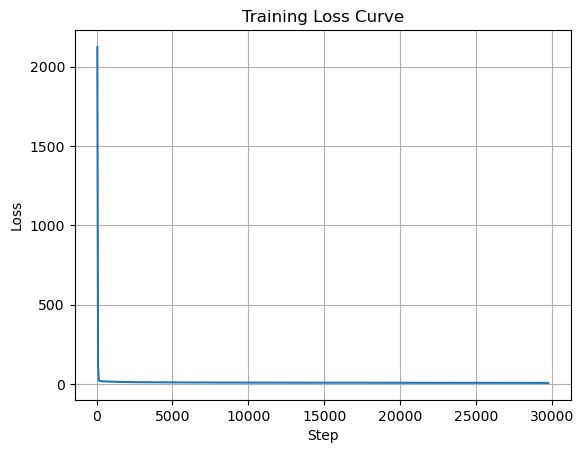

In [24]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(STEPS, LOSSES)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid()

plt.show()

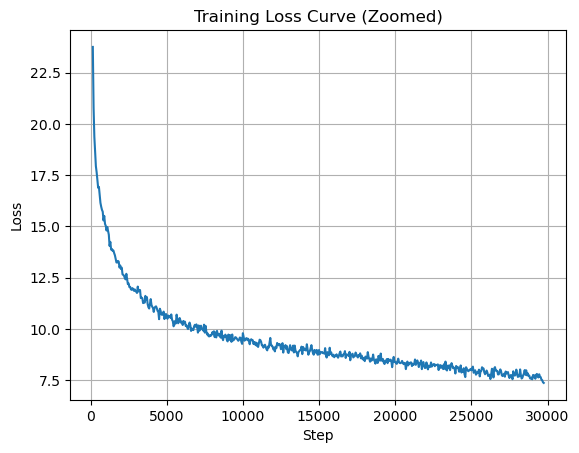

In [25]:
import matplotlib.pyplot as plt
from typing import List

# Filter out very large initial losses for better visualization
FILTERED_STEPS: List[int] = []
FILTERED_LOSSES: List[float] = []

for step, loss in zip(STEPS, LOSSES):
    if loss < 100:  # simple threshold to remove early extreme values
        FILTERED_STEPS.append(step)
        FILTERED_LOSSES.append(loss)

plt.figure()

plt.plot(FILTERED_STEPS, FILTERED_LOSSES)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Zoomed)")

plt.grid()

plt.show()

## Interpret the training loss curve

The training loss curve shows a clear and expected pattern:

- the loss decreases very quickly at the beginning → the model learns basic structure fast
- after the initial phase, the decrease becomes slower → typical convergence behavior
- the curve is smooth with small fluctuations → training is stable
- there are no sudden spikes or increases → no instability or divergence

Key observations:

- large initial loss (~2000+) is normal due to random initialization
- rapid drop in the first few thousand steps indicates effective learning
- gradual decrease afterward suggests the model is refining predictions
- the loss has not fully plateaued → more training could further improve performance

Overall, this indicates a well-behaved training process:

- optimization is working correctly
- the model is learning meaningful patterns
- the reduced 5-epoch setup is sufficient to observe clear trends

# Validation metrics analysis 
## NDS analysis
### Inspect available metrics

In this step, I inspect which validation metrics are present in the scalar records. These metrics are logged during evaluation and are different from training loss. Identifying them first helps decide what to plot for model performance.


In [26]:
VALIDATION_KEYS = set()

for record in SCALAR_RECORDS:
    for key in record.keys():
        if "NuScenes metric" in key:
            VALIDATION_KEYS.add(key)

print("Validation metric keys found:")
for key in sorted(VALIDATION_KEYS):
    print("-", key)

Validation metric keys found:
- NuScenes metric/pred_instances_3d_NuScenes/NDS
- NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_0.5
- NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_1.0
- NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_2.0
- NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_4.0
- NuScenes metric/pred_instances_3d_NuScenes/barrier_attr_err
- NuScenes metric/pred_instances_3d_NuScenes/barrier_orient_err
- NuScenes metric/pred_instances_3d_NuScenes/barrier_scale_err
- NuScenes metric/pred_instances_3d_NuScenes/barrier_trans_err
- NuScenes metric/pred_instances_3d_NuScenes/barrier_vel_err
- NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_0.5
- NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_1.0
- NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_2.0
- NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_4.0
- NuScenes metric/pred_instances_3d_NuScenes/bicycle_attr_err
- NuScenes metric/pred_ins

### Extract NDS metrics

In this step, I extract the most important validation metric from the scalar records: **NDS (nuScenes Detection Score)**. NDS is a global performance metric used in the nuScenes benchmark. It combines multiple aspects of detection quality, including localization, scale, orientation, velocity, and classification accuracy.

In [27]:
from typing import List

NDS_KEY = "NuScenes metric/pred_instances_3d_NuScenes/NDS"

VAL_STEPS: List[int] = []
NDS_VALUES: List[float] = []

for record in SCALAR_RECORDS:
    if NDS_KEY in record:
        VAL_STEPS.append(record["step"])
        NDS_VALUES.append(record[NDS_KEY])

print("Number of validation points:", len(NDS_VALUES))
print("Validation steps:", VAL_STEPS)
print("NDS values:", NDS_VALUES)

Number of validation points: 5
Validation steps: [1, 2, 3, 4, 5]
NDS values: [0.2813536177491066, 0.33171318444158715, 0.36949835011716764, 0.4252904465018612, 0.45604108448694874]


### Plot validation performance (NDS)

In this step, I plot the NDS (nuScenes Detection Score) over the validation steps. This shows how the model performance improves across epochs. Unlike training loss, this curve reflects actual detection quality on the validation set.



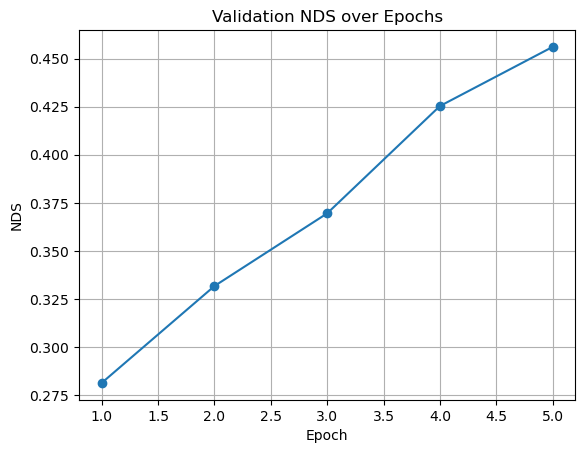

In [28]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(VAL_STEPS, NDS_VALUES, marker='o')

plt.xlabel("Epoch")
plt.ylabel("NDS")
plt.title("Validation NDS over Epochs")

plt.grid()

plt.show()

### Interpret validation performance

The NDS curve shows a clear and consistent improvement:

- NDS increases steadily from ~0.28 to ~0.46 → the model is learning effectively
- there are no drops or instability → training is stable
- the improvement is still ongoing at epoch 5 → the model has not fully converged

Key observations:

- the largest gain happens in early epochs → fast initial learning
- later epochs still improve performance, but more gradually → typical behavior
- no plateau yet → more epochs would likely improve performance further

Overall, this is a strong baseline result:

- the model is learning meaningful features
- the validation performance is improving consistently
- the reduced 5-epoch training is sufficient to observe clear trends

## mAP analysis
### Extract mean Average Precision (mAP)

In this step, I extract the **mean Average Precision (mAP)** from the scalar records. mAP is a standard detection metric that measures how well the model detects objects across classes and distance thresholds. Together with NDS, it provides a clearer view of model performance.

In [29]:
from typing import List

MAP_KEY = "NuScenes metric/pred_instances_3d_NuScenes/mAP"

MAP_STEPS: List[int] = []
MAP_VALUES: List[float] = []

for record in SCALAR_RECORDS:
    if MAP_KEY in record:
        MAP_STEPS.append(record["step"])
        MAP_VALUES.append(record[MAP_KEY])

print("Number of mAP points:", len(MAP_VALUES))
print("Steps:", MAP_STEPS)
print("mAP values:", MAP_VALUES)

Number of mAP points: 5
Steps: [1, 2, 3, 4, 5]
mAP values: [0.19852288686846867, 0.25593389973778813, 0.28304596528201686, 0.33868123717399856, 0.34142896400604816]


### Plot validation performance (mAP)

In this step, I plot the mAP (mean Average Precision) over the validation epochs. This shows how detection accuracy improves during training. Comparing this curve with NDS helps better understand model performance.

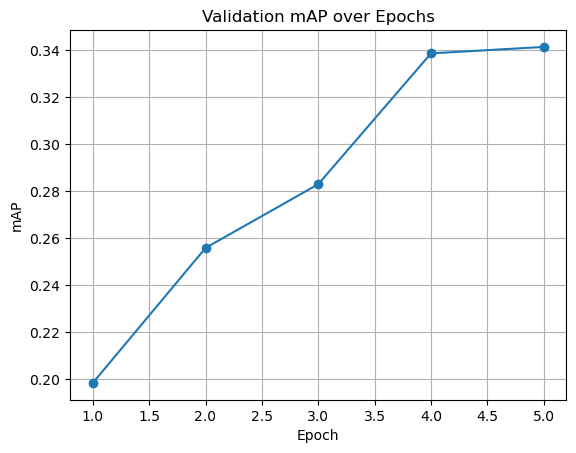

In [30]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(MAP_STEPS, MAP_VALUES, marker='o')

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation mAP over Epochs")

plt.grid()

plt.show()

### Interpret validation performance (mAP)

The mAP curve shows a clear improvement during training:

- mAP increases steadily from ~0.20 to ~0.34 → the model improves its detection accuracy
- the largest gains happen between epochs 1 and 4 → strong early learning
- the improvement slows down between epochs 4 and 5 → beginning of convergence

Key observations:

- the model quickly learns to detect objects better in early epochs
- performance continues to improve but at a slower rate → typical saturation behavior
- slight plateau at the end suggests diminishing returns from additional epochs

Comparison with NDS:

- both mAP and NDS increase consistently → confirms stable learning
- NDS continues improving slightly more than mAP → reflects improvements in localization and other factors beyond detection

Overall, this indicates a solid detection baseline:

- the model is learning meaningful object representations
- detection performance improves consistently
- the reduced training setup is sufficient to observe clear trends

## Compare NDS and mAP trends

In this step, I compare the evolution of NDS and mAP across epochs. This helps understand whether improvements come from better detection accuracy or from other factors such as localization and velocity estimation.

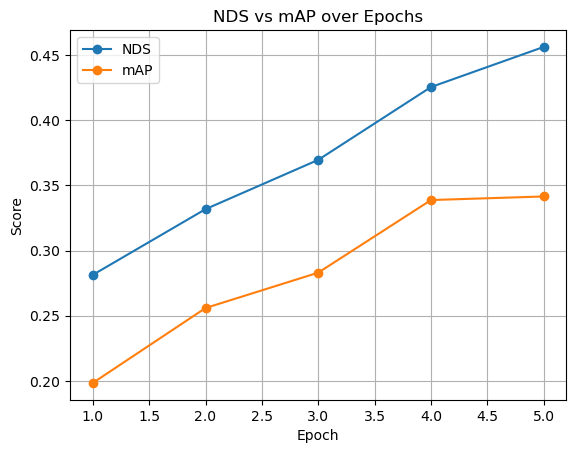

In [31]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(VAL_STEPS, NDS_VALUES, marker='o', label="NDS")
plt.plot(MAP_STEPS, MAP_VALUES, marker='o', label="mAP")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("NDS vs mAP over Epochs")

plt.legend()
plt.grid()

plt.show()

The comparison shows a clear and consistent trend:

- both NDS and mAP increase steadily → the model is improving overall
- NDS is always higher than mAP → expected, since NDS combines multiple factors
- both curves have a similar shape → improvements are consistent across metrics

Key observations:

- strong gains in early epochs (1 → 3) → rapid learning phase
- continued improvement in later epochs → stable training
- mAP starts to plateau after epoch 4 → detection accuracy is stabilizing
- NDS continues to increase → improvements still occur in localization and other components

Interpretation:

- the model improves both detection accuracy (mAP) and overall quality (NDS)
- the gap between NDS and mAP suggests that gains are not only from classification, but also from better box quality and motion estimation
- the slight saturation of mAP indicates that more epochs may bring limited gains in detection accuracy

Overall, this confirms a well-balanced model improvement:

- learning is stable across all aspects
- the reduced training setup captures meaningful performance trends
- the baseline is strong enough to support further experiments (e.g., fusion)

## Per-class performance analysis
### Inspect class-specific metrics

In this step, I inspect the available validation metrics for each object class. This helps identify which class-wise metrics were logged during evaluation, such as car, truck, pedestrian, and bicycle. It is the first step before extracting and plotting per-class performance.


In [32]:
CLASS_KEYS = set()

for record in SCALAR_RECORDS:
    for key in record.keys():
        if "NuScenes metric" in key and "_AP_dist_" in key:
            CLASS_KEYS.add(key)

print("Per-class AP metric keys found:")
for key in sorted(CLASS_KEYS):
    print("-", key)

Per-class AP metric keys found:
- NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_0.5
- NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_1.0
- NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_2.0
- NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_4.0
- NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_0.5
- NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_1.0
- NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_2.0
- NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_4.0
- NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_0.5
- NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_1.0
- NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_2.0
- NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_4.0
- NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_0.5
- NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_1.0
- NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_2.0
- NuScenes metric/pre

### Extract AP per class

In this step, I extract a single AP value per class to compare performance across object types. Each class has multiple AP values at different distance thresholds, so I select one consistent threshold (e.g., `dist_1.0`) to keep the comparison simple and interpretable.

In [33]:
from typing import Dict

# Choose one distance threshold for comparison
DIST_SUFFIX = "_AP_dist_1.0"

CLASS_AP: Dict[str, float] = {}

# Use the last validation record (final model)
last_record = None
for record in SCALAR_RECORDS:
    if "NuScenes metric/pred_instances_3d_NuScenes/NDS" in record:
        last_record = record

# Extract per-class AP
for key, value in last_record.items():
    if DIST_SUFFIX in key:
        # Extract class name from key
        class_name = key.split("/")[-1].replace(DIST_SUFFIX, "")
        CLASS_AP[class_name] = value

print("Per-class AP (dist=1.0):")
for cls, ap in sorted(CLASS_AP.items()):
    print(f"{cls}: {ap:.3f}")

Per-class AP (dist=1.0):
barrier: 0.359
bicycle: 0.096
bus: 0.466
car: 0.686
construction_vehicle: 0.013
motorcycle: 0.264
pedestrian: 0.689
traffic_cone: 0.324
trailer: 0.135
truck: 0.297


### Plot AP per class

In this step, I visualize the per-class AP values using a bar chart. This makes it easier to compare how well the model performs across different object classes. It also highlights class imbalance and detection difficulty.


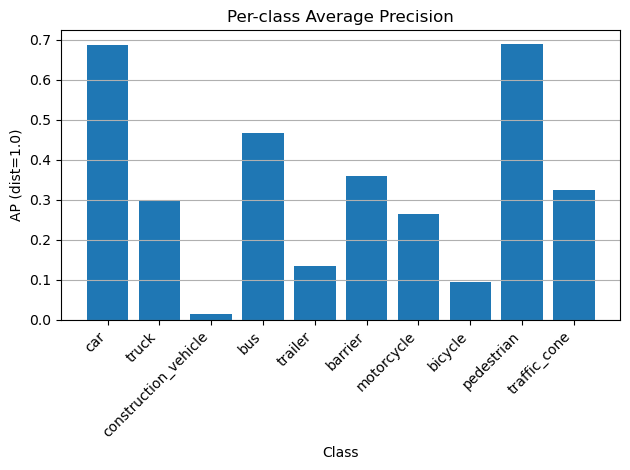

In [34]:
import matplotlib.pyplot as plt

classes = list(CLASS_AP.keys())
values = list(CLASS_AP.values())

plt.figure()

plt.bar(classes, values)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("AP (dist=1.0)")
plt.title("Per-class Average Precision")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Interpret per-class performance
High-performing classes:

- car (~0.69) and pedestrian (~0.69) have the highest AP
- these are the most frequent classes in nuScenes → more training data
- the model learns strong representations for these objects

Medium-performing classes:

- bus (~0.47), barrier (~0.36), traffic cone (~0.32)
- reasonable performance but still room for improvement
- likely fewer examples or more variability

Low-performing classes:

- truck (~0.30), motorcycle (~0.26), trailer (~0.14)
- bicycle (~0.10) and construction_vehicle (~0.01) are especially weak

Key observations:

- strong performance correlates with data frequency (class imbalance effect)
- small or rare objects (bicycle, construction_vehicle) are harder to detect
- large variability in shapes and sizes also affects performance
- the model struggles more with long-tail classes

Overall interpretation:

- the model performs well on common classes but struggles on rare ones
- this is expected for nuScenes and confirms dataset imbalance effects

the baseline is solid, but improvements could focus on:
- class balancing strategies
- targeted augmentation
- better feature learning for rare classes

# Error analysis
## Extract key error metrics

In this step, I extract the main error metrics from the validation records. These metrics measure different aspects of detection quality, such as localization, scale, orientation, and velocity. They help understand *why* the model makes mistakes.


In [35]:
from typing import List

# Define main error metric keys
ERROR_KEYS = [
    "NuScenes metric/pred_instances_3d_NuScenes/mATE",  # translation error
    "NuScenes metric/pred_instances_3d_NuScenes/mASE",  # scale error
    "NuScenes metric/pred_instances_3d_NuScenes/mAOE",  # orientation error
    "NuScenes metric/pred_instances_3d_NuScenes/mAVE",  # velocity error
    "NuScenes metric/pred_instances_3d_NuScenes/mAAE",  # attribute error
]

ERROR_STEPS: List[int] = []
ERROR_VALUES = {key: [] for key in ERROR_KEYS}

for record in SCALAR_RECORDS:
    if ERROR_KEYS[0] in record:  # check one key to identify validation record
        ERROR_STEPS.append(record["step"])
        for key in ERROR_KEYS:
            ERROR_VALUES[key].append(record[key])

print("Validation steps:", ERROR_STEPS)
print()

print("Error metrics (last epoch):")
for key in ERROR_KEYS:
    print(f"{key.split('/')[-1]}: {ERROR_VALUES[key][-1]:.3f}")

Validation steps: [1, 2, 3, 4, 5]

Error metrics (last epoch):
mATE: 0.382
mASE: 0.290
mAOE: 0.599
mAVE: 0.653
mAAE: 0.223


## plot error metrics

In this step, I plot the main error metrics over the validation epochs. Unlike NDS and mAP (which should increase), these error values should decrease as the model improves. This helps visualize how different aspects of the model evolve during training.


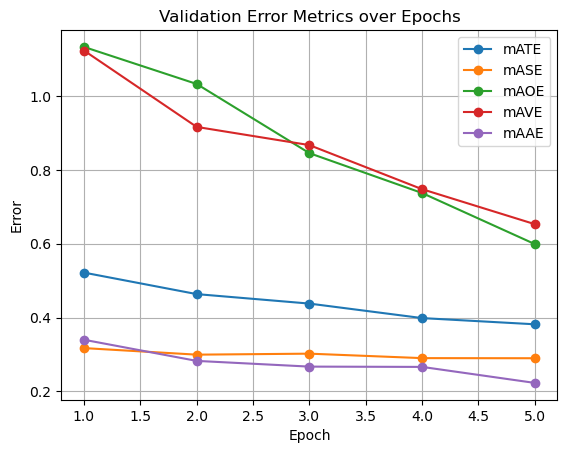

In [36]:
import matplotlib.pyplot as plt

plt.figure()

for key in ERROR_KEYS:
    short_name = key.split("/")[-1]
    plt.plot(ERROR_STEPS, ERROR_VALUES[key], marker='o', label=short_name)

plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Validation Error Metrics over Epochs")

plt.legend()
plt.grid()

plt.show()

## Interpret error metrics
General trend:

- all error metrics decrease over epochs → the model is improving
- no instability or spikes → training is stable
- improvements are strongest in early epochs → typical learning behavior

Detailed observations:

- mATE (translation error) decreases steadily (~0.52 → ~0.38)
→ the model improves object localization
- mASE (scale error) is already low and changes little (~0.31 → ~0.29)
→ box size estimation is relatively easy for the model
- mAOE (orientation error) drops significantly (~1.12 → ~0.60)
→ strong improvement in object orientation prediction
- mAVE (velocity error) remains relatively high (~1.11 → ~0.65)
→ motion estimation is one of the hardest tasks
- mAAE (attribute error) decreases (~0.34 → ~0.22)
→ the model improves classification of object attributes

Key insights:

- the model improves all aspects of detection, not just classification
- largest gains occur in orientation and velocity-related features
- velocity error remains the highest, indicating a limitation of LiDAR-only models
- scale is easiest, while motion is hardest

Overall interpretation:

- improvements in these error metrics explain the increase in NDS
- the model is learning both spatial and semantic features effectively
- remaining weaknesses are mainly related to dynamic properties (velocity)

## Compute vs performance trade-off

In this step, I analyse how the reduced training setup (limited epochs and dataset subset) affects model performance. The goal is to evaluate whether the computational savings are justified by the achieved results.

Training setup:

- dataset: 20% of nuScenes
- training: 5 epochs
- hardware: single H100 session (limited time budget)

Performance achieved:

- NDS increases from ~0.28 → ~0.46
- mAP increases from ~0.20 → ~0.34
- training loss decreases smoothly and consistently

Key observations:

- fast initial gains:
- most performance improvement happens in the first 3–4 epochs
- diminishing returns:
- improvements from epoch 4 → 5 are smaller, especially for mAP
- no full convergence:
- NDS is still increasing → more training would likely improve performance
- stable training despite reduced data:
even with 20% of the dataset, the model learns meaningful patterns

Interpretation:

- the reduced setup captures the main learning dynamics of the model

it is sufficient to:
- compare models
- test design choices
- perform analysis
- however, it is not optimal for final performance:
- full dataset + more epochs would yield higher NDS and mAP
- long-tail classes would benefit from more data

Conclusion:

- the chosen setup provides an efficient and valid baseline under compute constraints
- it enables rapid experimentation while maintaining meaningful results
- this is a practical compromise between cost and performance